# Éclairage public & économies d'énergie - Communes françaises

**Données :** `ore_cerema_merged_allcols.csv`
- **482 779 lignes** - consommation électrique + gaz par commune × année × secteur NAF (2011–2024)
- **Variables CEREMA intégrées :** `extinction_totale`, `annee_extinction`, `renovation`, `luminosite_annuelle`...
- **11 978 communes** avec extinction déclarée - adoption échelonnée 2014–2024
- **1 366 communes** avec données NAF84 (administration publique proxy de éclairage public)




## 0. Imports & configuration

In [ ]:
!pip install -r requirements.txt

In [ ]:
!pip install git+https://github.com/d2cml-ai/DRDID # pour l'estimation robuste de C&S

  Cloning https://github.com/d2cml-ai/DRDID to c:\users\zargo\appdata\local\temp\pip-req-build-skqvqt__
  Resolved https://github.com/d2cml-ai/DRDID to commit 75cac04ee98959ccf1c06df80fa447cc20c8fa42
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for drdid: filename=drdid-1.1.6-py3-none-any.whl size=9703 sha256=46a0e767ec44062f2463d5d634fc60a9d27b8a9b49d159ebe54be8d4b1df8e24
  Stored in directory: C:\Users\zargo\AppData\Local\Temp\pip-ephem-wheel-cache-h45qbfoa\wheels\bd\21\1a\b47917442e9a4973a8f55ba05fff84a33641f5ae20fede75db
Successfully built drdid


  Running command git clone --filter=blob:none --quiet https://github.com/d2cml-ai/DRDID 'C:\Users\zargo\AppData\Local\Temp\pip-req-build-skqvqt__'


In [1]:
import warnings, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from linearmodels.panel import PanelOLS
from linearmodels.panel.results import PanelEffectsResults
from csdid.att_gt import ATTgt
try:
    import ruptures as rpt
    HAS_RUPTURES = True
except ImportError:
    HAS_RUPTURES = False
    print("ruptures non installé - pip install ruptures")

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

#  Chemin du fichier 
DATA_PATH = Path(r"C:\Users\zargo\Documents\ENSAE 3A\Economics of Energy Markets\ore_cerema_merged_allcols.csv")

plt.rcParams.update({
    "figure.facecolor":"white", "axes.facecolor":"white",
    "axes.spines.top":False, "axes.spines.right":False,
    "axes.grid":True, "grid.alpha":0.3, "font.size":11,
})
BLUE, RED, GRAY = "#185FA5", "#C0392B", "#AAAAAA"
Path("figures").mkdir(exist_ok=True)
print("Setup OK")

Setup OK



## 1. Chargement & exploration de la base fusionnée

Chargement de la base (peut prendre environ 30s)...
Taille: 95,227 lignes × 18 colonnes
  Communes    : 15,101
  Communes complètes : 11,736


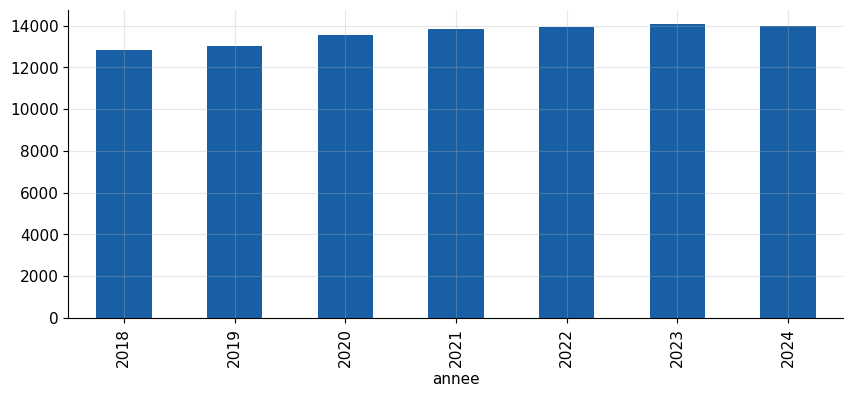

In [2]:
print("Chargement de la base (peut prendre environ 30s)...")
panel = pd.read_parquet("C:/Users/zargo/Documents/ENSAE 3A/Economics of Energy Markets/panel.parquet")
panel = panel.drop(columns=["annee"]).rename(columns={
    "Code Commune": "code_commune",
    "Année": "annee"})

print(f"Taille: {len(panel):,} lignes × {panel.shape[1]} colonnes")

# Filtrer électricité uniquement
print(f"  Communes    : {panel['code_commune'].nunique():,}")
panel['annee'].value_counts().sort_index().plot(kind='bar', color=BLUE, figsize=(10, 4))


# Garder les communes pour lesquelles on a un panel équilibré (2018-2024)
n_years = panel['annee'].max() - panel['annee'].min() + 1
communes_completes = panel.groupby("code_commune")["annee"].nunique() == n_years
communes_completes = communes_completes[communes_completes].index
panel = panel[panel["code_commune"].isin(communes_completes)].copy()
print(f"  Communes complètes : {panel['code_commune'].nunique():,}")


## 2. Construction du panel commune × année

### 2.1 Panel NAF84 (administration publique ≈ éclairage public)

Le secteur NAF 84 = *Administration publique et défense* est le proxy de l'éclairage public dans les données ORE.


In [3]:
# ── Merger NAF84 + total pour calculer la part NAF84 dans la conso totale
CEREMA_STATIC = [
    "extinction_totale","renovation","abandon","extension",
    "annee_extinction","annee_renovation","annee_abandon_extinction","annee_extension",
    "luminosite_annuelle","luminosite_totale","nb_mois_luminosite"
]



print(f" Panel : {panel['code_commune'].nunique():,} communes × {panel['annee'].nunique()} années = {len(panel):,} obs")
print(f" Période : {panel['annee'].min()}–{panel['annee'].max()}")
print(f"Part NAF84 moyenne : {panel['naf84_share'].mean():.3f}")
panel.head(4)

 Panel : 11,736 communes × 7 années = 82,204 obs
 Période : 2018–2024
Part NAF84 moyenne : 0.027


,code_commune,annee,conso_naf84_mwh,conso_totale_mwh,extinction_totale,renovation,abandon,extension,annee_extinction,annee_renovation,annee_abandon_extinction,annee_extension,luminosite_totale,nb_mois_luminosite,luminosite_annuelle,naf84_share,ln_naf84,ln_total
0,01001,2018,211.314,"3,245.912",0.000,0.000,0.000,0.000,NaN,NaN,NaN,NaN,2.462,132.000,2.684,0.065,5.353,8.085
1,01001,2019,211.392,"3,244.388",0.000,0.000,0.000,0.000,NaN,NaN,NaN,NaN,2.462,132.000,2.590,0.065,5.354,8.085
2,01001,2020,21.580,"3,351.850",0.000,0.000,0.000,0.000,NaN,NaN,NaN,NaN,2.462,132.000,2.291,0.006,3.072,8.117
3,01001,2021,15.522,"3,597.381",0.000,0.000,0.000,0.000,NaN,NaN,NaN,NaN,2.462,132.000,2.255,0.004,2.742,8.188


### 2.2 Variables de traitement (depuis CEREMA)

In [4]:
#  Variables de traitement 

panel["treated"] = panel["extinction_totale"] == 1.0
panel["annee_extinction"] = pd.to_numeric(panel["annee_extinction"], errors="coerce")

# Post-traitement : 1 si l'année >= première extinction
panel["post"] = (
    panel["treated"] &
    panel["annee_extinction"].notna() &
    (panel["annee"] >= panel["annee_extinction"])
)

# Event-time (années relatives à l'extinction)
panel["event_time"] = np.where(
    panel["annee_extinction"].notna(),
    panel["annee"] - panel["annee_extinction"],
    np.nan
)

# Traitement "propre" : extinction sans renovation simultanée (pour robustesse)
panel["treated_clean"] = panel["treated"] & (panel["renovation"] == 0.0)

n_treated  = panel[panel["treated"]]["code_commune"].nunique()
n_total    = panel["code_commune"].nunique()
n_post_obs = panel["post"].sum()

print(f" Traitement intégré")
print(f"  Communes traitées (extinction)     : {n_treated:,} / {n_total:,} ({100*n_treated/n_total:.0f}%)")
print(f"  Obs post-traitement                : {n_post_obs:,}")
print(f"  Communes traitées 'propres' (sans rénovation simultanée) : {panel[panel['treated_clean']]['code_commune'].nunique():,}")
print()
print("Distribution des event-times :")
print(panel["event_time"].value_counts().sort_index().to_string())

 Traitement intégré
  Communes traitées (extinction)     : 6,163 / 11,736 (53%)
  Obs post-traitement                : 25,679
  Communes traitées 'propres' (sans rénovation simultanée) : 5,133

Distribution des event-times :
event_time
-6.000     115
-5.000    1131
-4.000    3525
-3.000    3890
-2.000    4185
-1.000    4642
0.000     4986
1.000     5218
2.000     4524
3.000     2529
4.000     2277
5.000     1981
6.000     1525
7.000     1182
8.000      835
9.000      511
10.000     111


## 3. Analyse descriptive

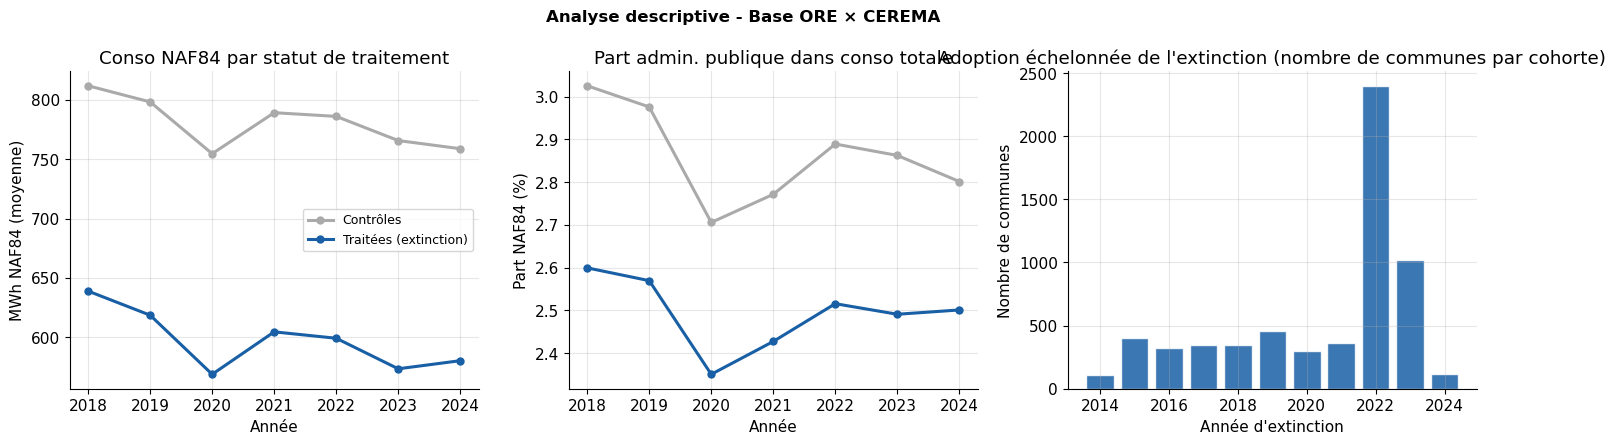

 Sauvegardé vers figures/fig1_descriptive.pdf


In [5]:
#  Figure 1 : tendances agrégées 
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Conso NAF84 moyenne par statut
ax = axes[0]
agg = panel.groupby(["annee","treated"])["conso_naf84_mwh"].mean().reset_index()
for treated, grp in agg.groupby("treated"):
    c, lbl = (BLUE, "Traitées (extinction)") if treated else (GRAY, "Contrôles")
    ax.plot(grp["annee"], grp["conso_naf84_mwh"], color=c, lw=2.2, marker="o", ms=5, label=lbl)
ax.set_xlabel("Année"); ax.set_ylabel("MWh NAF84 (moyenne)")
ax.set_title("Conso NAF84 par statut de traitement")
ax.legend(fontsize=9)

# Part NAF84
ax = axes[1]
agg2 = panel.groupby(["annee","treated"])["naf84_share"].mean().reset_index()
for treated, grp in agg2.groupby("treated"):
    c = BLUE if treated else GRAY
    ax.plot(grp["annee"], grp["naf84_share"]*100, color=c, lw=2.2, marker="o", ms=5)
ax.set_xlabel("Année"); ax.set_ylabel("Part NAF84 (%)")
ax.set_title("Part admin. publique dans conso totale")

# Distribution années extinction (staggered adoption)
ax = axes[2]
ext_by_year = panel[panel["treated"]].drop_duplicates("code_commune")["annee_extinction"].value_counts().sort_index()
ax.bar(ext_by_year.index, ext_by_year.values, color=BLUE, alpha=0.85, edgecolor="white")
ax.set_xlabel("Année d'extinction"); ax.set_ylabel("Nombre de communes")
ax.set_title("Adoption échelonnée de l'extinction (nombre de communes par cohorte)")

fig.suptitle("Analyse descriptive - Base ORE × CEREMA", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig("figures/fig1_descriptive.pdf", bbox_inches="tight")
plt.show()
print(f" Sauvegardé vers figures/fig1_descriptive.pdf")

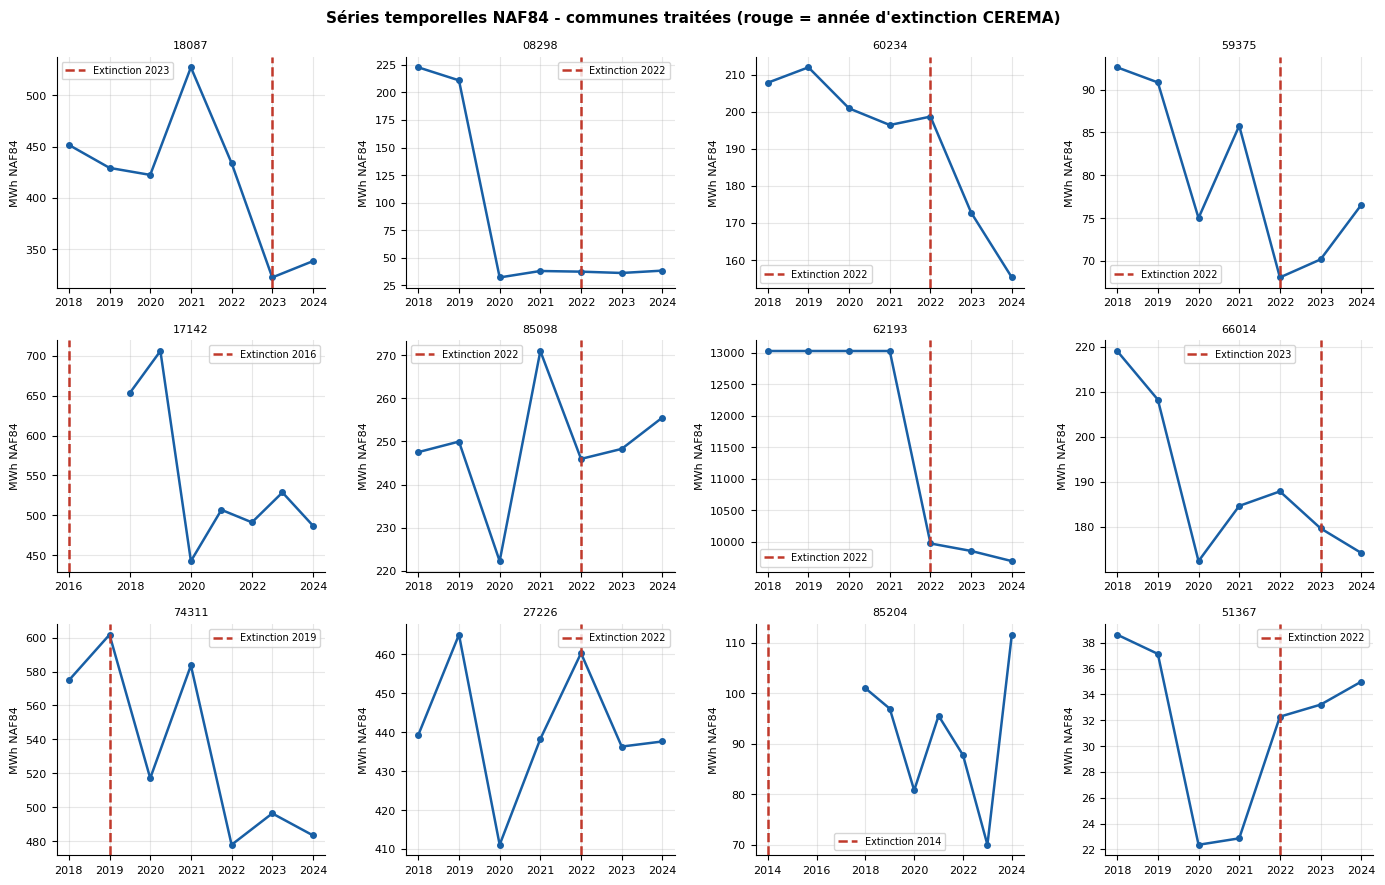

In [6]:
# ── Figure 2 : séries individuelles ─────────────────────────────────────────
np.random.seed(42)
treated_units = panel[panel["treated"] & panel["annee_extinction"].notna()]["code_commune"].unique()
sample = np.random.choice(treated_units, size=min(12, len(treated_units)), replace=False)

ncols = 4; nrows = int(np.ceil(len(sample)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows*3))
axes = axes.flatten()

for ax, cid in zip(axes, sample):
    sub = panel[panel["code_commune"]==cid].sort_values("annee")
    ty  = sub["annee_extinction"].iloc[0]
    ax.plot(sub["annee"], sub["conso_naf84_mwh"], color=BLUE, lw=1.8, marker="o", ms=4)
    if pd.notna(ty):
        ax.axvline(ty, color=RED, lw=1.8, linestyle="--", label=f"Extinction {int(ty)}")
        ax.legend(fontsize=7)
    name = sub["nom_commune"].iloc[0] if "nom_commune" in sub.columns else cid
    ax.set_title(str(name)[:28], fontsize=8)
    ax.set_ylabel("MWh NAF84", fontsize=8)
    ax.tick_params(labelsize=8)

for ax in list(axes)[len(sample):]:
    ax.set_visible(False)

fig.suptitle("Séries temporelles NAF84 - communes traitées (rouge = année d'extinction CEREMA)",
             fontsize=11, fontweight="bold")
fig.tight_layout()
fig.savefig("figures/fig2_series.pdf", bbox_inches="tight")
plt.show()

In [25]:
#  Tableau récapitulatif sur les périodes pré-traitement uniquement

desc = (
    panel[(panel['event_time']<=0 )| (panel['treated']==False)].groupby("treated")
    .agg(
        n_communes     = ("code_commune", "nunique"),
        n_obs          = ("code_commune", "count"),
        naf84_mwh_moy  = ("conso_naf84_mwh", "mean"),
        naf84_mwh_med  = ("conso_naf84_mwh", "median"),
        naf84_share_moy= ("naf84_share", "mean"),
        luminosite_moy = ("luminosite_annuelle", "mean"),
    ).round(3)
)
desc.index = ["Contrôles","Traitées"]
desc.columns = ["N communes","N obs","MWh moy","MWh médian","Part NAF84","Luminosité moy"]
print("Statistiques descriptives")
display(desc)

Statistiques descriptives


,N communes,N obs,MWh moy,MWh médian,Part NAF84,Luminosité moy
Contrôles,5573,39037,780.647,98.429,0.029,5.289
Traitées,4983,22474,675.414,169.350,0.025,6.285


### 3.2 Détection de ruptures structurelles (PELT)

On vérifie si la consommation NAF84 montre une rupture à la baisse concordante avec la date d'extinction CEREMA.


In [8]:
def detect_breaks_pelt(series_dict, years):
    if not HAS_RUPTURES:
        return []
    vals = np.array([series_dict.get(y, np.nan) for y in years], dtype=float)
    if np.sum(~np.isnan(vals)) < 5:
        return []
    vals = np.nan_to_num(vals, nan=np.nanmean(vals[~np.isnan(vals)]))
    n = len(vals)
    pen = np.log(n) * np.var(vals)
    try:
        algo = rpt.Pelt(model="l2", min_size=2).fit(vals)
        bkpts = algo.predict(pen=pen)
        return [years[i-1] for i in bkpts[:-1] if 0 < i <= len(years)]
    except:
        return []

YEARS = list(range(2018, 2025))  # Plage de données NAF84 disponibles

print("Détection de ruptures en cours...")
results = []
units = panel["code_commune"].unique()

for uid in units:
    sub = panel[panel["code_commune"]==uid].set_index("annee")["conso_naf84_mwh"]
    treated = panel[panel["code_commune"]==uid]["treated"].mode()[0]
    ty = panel[panel["code_commune"]==uid]["annee_extinction"].mode()
    ty = float(ty[0]) if len(ty) > 0 and pd.notna(ty[0]) else np.nan

    bkpts = detect_breaks_pelt(sub.to_dict(), YEARS)

    direction = None
    if bkpts:
        idx = YEARS.index(bkpts[0])
        vals = [sub.get(y, np.nan) for y in YEARS]
        before = np.nanmean(vals[max(0,idx-2):idx])
        after  = np.nanmean(vals[idx:min(len(vals),idx+2)])
        direction = "downward" if (before > 0 and after < before) else "upward"

    if not treated:
        status = "control"
    elif not bkpts:
        status = "no_break"
    elif pd.notna(ty) and any(abs(b-ty) <= 2 for b in bkpts):
        status = "concordant"
    else:
        status = "non_concordant"

    results.append({
        "code_commune": uid, "treated": treated,
        "annee_extinction": ty, "detected_breaks": bkpts,
        "first_break_year": bkpts[0] if bkpts else np.nan,
        "status": status, "break_direction": direction,
    })

break_df = pd.DataFrame(results)
print(break_df["status"].value_counts())
concordant_rate = (break_df[break_df["treated"]]["status"]=="concordant").mean()
print(f"\nTaux de concordance parmi les traités : {concordant_rate:.1%}")

Détection de ruptures en cours...
status
control           5573
no_break          3446
concordant        1850
non_concordant     867
Name: count, dtype: int64

Taux de concordance parmi les traités : 30.0%


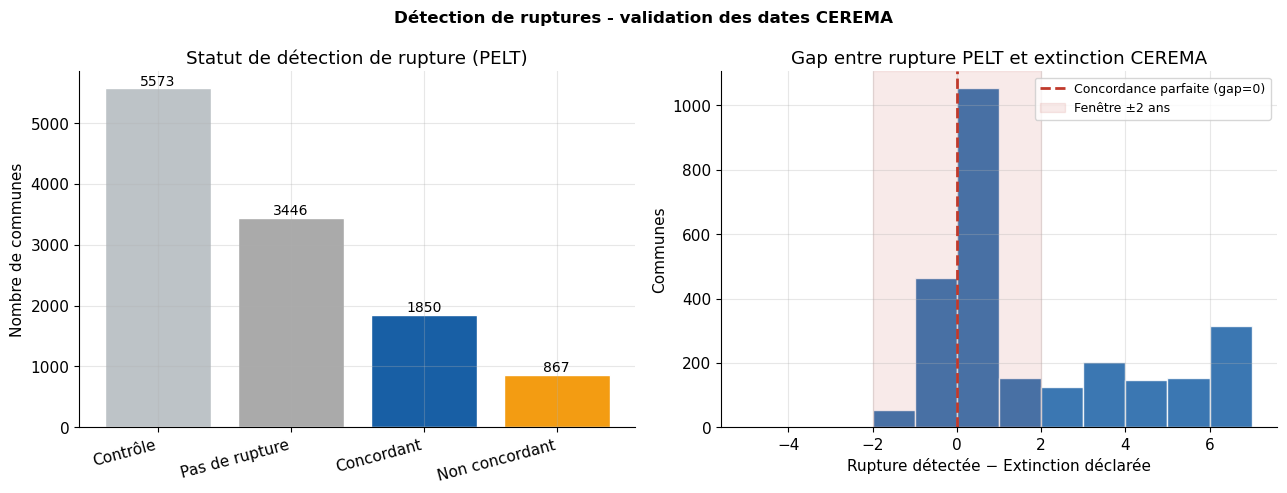

In [9]:
#  Figure 3 : résultats détection de ruptures 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
counts = break_df["status"].value_counts()
colors_map = {"concordant":BLUE,"non_concordant":"#F39C12","no_break":GRAY,"control":"#BDC3C7"}
bars = ax.bar(counts.index, counts.values,
              color=[colors_map.get(s, GRAY) for s in counts.index], edgecolor="white")
ax.bar_label(bars, fmt="%d", fontsize=10)
ax.set_ylabel("Nombre de communes"); ax.set_title("Statut de détection de rupture (PELT)")
ax.set_xticklabels(["Contrôle", "Pas de rupture", "Concordant", "Non concordant"],
                   rotation=15, ha="right")

ax = axes[1]
conc = break_df[break_df["status"].isin(["concordant","non_concordant"])].copy()
conc["gap"] = conc["first_break_year"] - conc["annee_extinction"]
conc["gap"].dropna().hist(bins=range(-5,8), ax=ax, color=BLUE, edgecolor="white", alpha=0.85)
ax.axvline(0, color=RED, lw=2, linestyle="--", label="Concordance parfaite (gap=0)")
ax.axvspan(-2, 2, alpha=0.1, color=RED, label="Fenêtre ±2 ans")
ax.set_xlabel("Rupture détectée − Extinction déclarée"); ax.set_ylabel("Communes")
ax.set_title("Gap entre rupture PELT et extinction CEREMA")
ax.legend(fontsize=9)

fig.suptitle("Détection de ruptures - validation des dates CEREMA", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig("figures/fig3_breaks.pdf", bbox_inches="tight")
plt.show()


## 4. Sélection du sous-échantillon à fort éclairage public

Deux approches :
- **(i) Critère de base :** part NAF84 relativement élevée dans la conso totale
- **(ii) Critère issu de mesures alternatives :** luminosité annuelle comme proxy direct d'intensité d'éclairage public (variable CEREMA)


In [26]:
#  Caractéristiques pré-période (avant 2021 pour éviter contamination) 
pre = panel[panel["annee"] <= 2020]

chars = (
    pre.groupby("code_commune")
    .agg(
        mean_naf84_mwh   = ("conso_naf84_mwh", "mean"),
        std_naf84_mwh    = ("conso_naf84_mwh", "std"),
        mean_total_mwh   = ("conso_totale_mwh", "mean"),
        mean_naf84_share = ("naf84_share", "mean"),
        luminosite_moy   = ("luminosite_annuelle", "mean"),
    )
    .reset_index()
)
chars["cv_naf84"] = chars["std_naf84_mwh"] / chars["mean_naf84_mwh"].clip(lower=1)
chars["log_mean_total"] = np.log(chars["mean_total_mwh"].clip(lower=1))

#  Approche (i) : seuil sur la part NAF84 
threshold_share = chars["mean_naf84_share"].quantile(0.70)
chars["selected_theory"] = chars["mean_naf84_share"] >= threshold_share
print(f"Seuil NAF84 share (p70) : {threshold_share:.4f}")
print(f"Sélectionnés (théorie)  : {chars['selected_theory'].sum():,} communes ({chars['selected_theory'].mean():.1%})")

#  Approche (ii) : luminosité CEREMA comme proxy direct 
# La luminosite_annuelle = intensité lumineuse mesurée par satellite.
# Un seuil élevé signifie que la commune est très éclairée vers l'extinction a plus d'impact
if chars["luminosite_moy"].notna().sum() > 100:
    threshold_lum = chars["luminosite_moy"].quantile(0.70)
    chars["selected_lum"] = chars["luminosite_moy"] >= threshold_lum
    print(f"\nSeuil luminosité (p70)  : {threshold_lum:.4f}")
    print(f"Sélectionnés (luminosité): {chars['selected_lum'].sum():,} communes ({chars['selected_lum'].mean():.1%})")
else:
    chars["selected_lum"] = chars["selected_theory"]
    print("\n Luminosité insuffisante - utilisation du critère NAF84 uniquement")

#  Union des deux approches 
chars["selected"]        = chars["selected_theory"] | chars["selected_lum"]
chars["selected_robust"] = chars["selected_theory"] & chars["selected_lum"]

print(f"\nSélectionnés (union)        : {chars['selected'].sum():,}")
print(f"Sélectionnés (intersection)  : {chars['selected_robust'].sum():,}")

Seuil NAF84 share (p70) : 0.0262
Sélectionnés (théorie)  : 3,521 communes (30.0%)

Seuil luminosité (p70)  : 5.0700
Sélectionnés (luminosité): 3,520 communes (30.0%)

Sélectionnés (union)        : 5,788
Sélectionnés (intersection)  : 1,253


Panel principal  : 5,788 communes | 40,561 obs
Panel robuste    : 1,253 communes | 8,790 obs


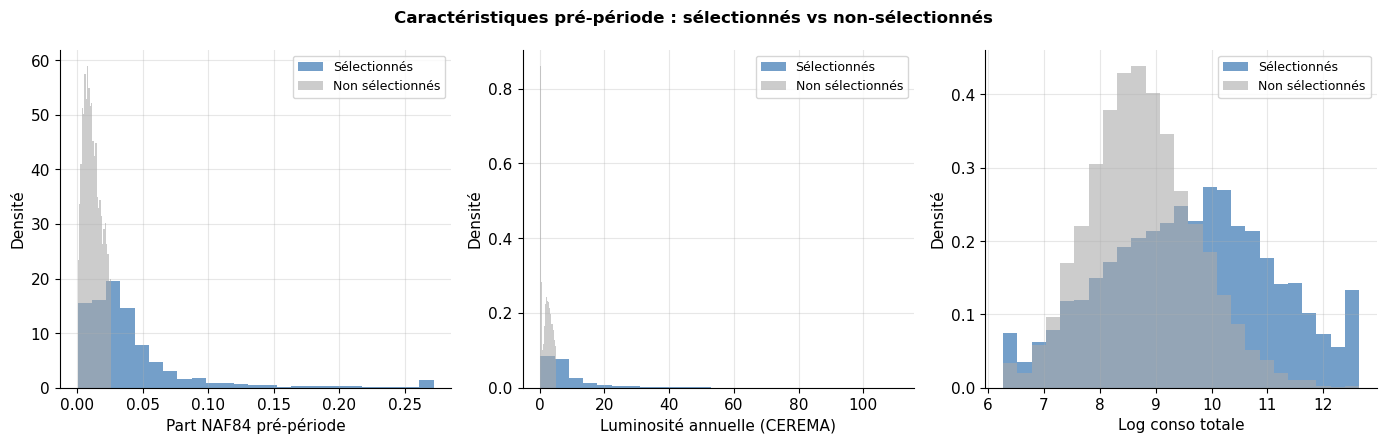

In [27]:
#  Merger la sélection dans le panel + données de rupture 
panel = panel.merge(
    chars[["code_commune","mean_naf84_share","luminosite_moy","selected","selected_robust"]],
    on="code_commune", how="left"
)
panel = panel.merge(
    break_df[["code_commune","status","break_direction","first_break_year"]],
    on="code_commune", how="left"
)
panel["selected"] = panel["selected"].fillna(False)
panel["selected_robust"] = panel["selected_robust"].fillna(False)  # ← ajouter

panel_sel = panel[panel["selected"]].copy()
panel_rob = panel[panel["selected_robust"]].copy()

print(f"Panel principal  : {panel_sel['code_commune'].nunique():,} communes | {len(panel_sel):,} obs")
print(f"Panel robuste    : {panel_rob['code_commune'].nunique():,} communes | {len(panel_rob):,} obs")

#  Figure 4 : sélectionnés vs non-sélectionnés 
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, col, label in zip(
    axes,
    ["mean_naf84_share","luminosite_moy","log_mean_total"],
    ["Part NAF84 pré-période","Luminosité annuelle (CEREMA)","Log conso totale"]
):
    for sel, lbl, c in [(True,"Sélectionnés",BLUE),(False,"Non sélectionnés",GRAY)]:
        vals = chars[chars["selected"]==sel][col].dropna()
        ax.hist(vals, bins=25, alpha=0.6, color=c, label=lbl, density=True)
    ax.set_xlabel(label); ax.set_ylabel("Densité"); ax.legend(fontsize=9)

fig.suptitle("Caractéristiques pré-période : sélectionnés vs non-sélectionnés",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig("figures/fig4_selection.pdf", bbox_inches="tight")
plt.show()


## 5. Estimation causale (DiD)

### 5.1 TWFE - Two-Way Fixed Effects (baseline)

$$\ln(\text{NAF84}_{it}) = \alpha_i + \gamma_t + \beta \cdot \text{Post}_{it} + \varepsilon_{it}$$

**Avantage avec cette base :** on peut aussi inclure la luminosité comme variable de contrôle et tester la robustesse sur les communes avec `renovation=0` (extinction pure).


### 5.2 Event-study - test de pre-trends

In [28]:
from linearmodels.panel import PanelOLS
from linearmodels.panel.results import PanelEffectsResults

def run_twfe(df, outcome="ln_naf84", id_col="code_commune", label="", extra_controls=None):

    d = df.dropna(subset=[id_col, "annee", outcome, "post"]).copy()
    if d[id_col].nunique() < 5:
        print(f"   Trop peu d'unités ({d[id_col].nunique()}) — TWFE impossible")
        return None

    d["post_int"] = d["post"].astype(int)

    # PanelOLS requires a MultiIndex (entity, time)
    d = d.set_index([id_col, "annee"])


    exog_cols = ["post_int"]
    if extra_controls:
        exog_cols += extra_controls

    mod = PanelOLS(
        dependent=d[outcome],
        exog=d[exog_cols],
        entity_effects=True,
        time_effects=True,
        drop_absorbed=True,
    )
    res = mod.fit(cov_type="clustered", cluster_entity=True)

    b   = res.params["post_int"]
    se  = res.std_errors["post_int"]
    p   = res.pvalues["post_int"]
    ci  = res.conf_int().loc["post_int"]
    pct = 100 * (np.exp(b) - 1)

    print(f"\nTWFE {label} : résultat")
    print(f"  β = {b:.4f}  SE = {se:.4f}  p = {p:.3f}")
    print(f"  IC95% : [{ci['lower']:.4f}, {ci['upper']:.4f}]")
    print(f"  Effet estimé : {pct:.2f}% de variation de la conso NAF84")
    print(f"  N = {int(res.nobs):,} obs, {d.index.get_level_values(0).nunique():,} communes")
    print(res.summary.tables[1])   # affiche le tableau de coefficients complet

    return {
        "beta": b, "se": se, "pval": p,
        "ci_lo": ci["lower"], "ci_hi": ci["upper"],
        "n_obs": int(res.nobs),
        "n_units": d.index.get_level_values(0).nunique(),
        "pct_effect": pct,
    }

res_main  = run_twfe(panel_sel,   label="(panel sélectionné)")
res_rob   = run_twfe(panel_rob,   label="(panel robuste)")
panel_clean = panel_sel[panel_sel["renovation"] == 0.0]
res_clean = run_twfe(panel_clean, label="(extinction pure, sans rénovation)")


TWFE (panel sélectionné) : résultat
  β = 0.0433  SE = 0.0115  p = 0.000
  IC95% : [0.0207, 0.0658]
  Effet estimé : 4.42% de variation de la conso NAF84
  N = 40,561 obs, 5,788 communes
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
post_int       0.0433     0.0115     3.7581     0.0002      0.0207      0.0658

TWFE (panel robuste) : résultat
  β = -0.0373  SE = 0.0209  p = 0.075
  IC95% : [-0.0783, 0.0038]
  Effet estimé : -3.66% de variation de la conso NAF84
  N = 8,790 obs, 1,253 communes
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
post_int      -0.0373     0.0209    -1.7797     0.0752     -0.0783      0

### 5.3 Callaway & Sant'Anna (2021)

In [35]:
def callaway_santanna(df, outcome="ln_naf84", id_col="code_commune"):
    d = df.dropna(subset=[id_col, "annee", outcome]).copy()
    d["gname"] = d["annee_extinction"].fillna(0).astype(int)

    # csdid requires numeric id — convert commune code to integer index
    d["unit_id"] = d[id_col].astype("category").cat.codes.astype(int)

    d = d[["unit_id", "annee", outcome, "gname"]].copy()

    print("Callaway & Sant'Anna en cours (csdid)...")
    cs = ATTgt(
        yname=outcome,
        tname="annee",
        idname="unit_id",        # ← numeric id, not the string commune code
        gname="gname",
        data=d,
        control_group="nevertreated",
        anticipation=0,
    ).fit()

    agg = cs.aggte(typec="simple")
    dyn = cs.aggte(typec="dynamic")

    theta_cs = agg.atte['overall_att']

    return theta_cs, agg, dyn


theta_cs, agg, dyn = callaway_santanna(panel_sel)

Callaway & Sant'Anna en cours (csdid)...
Dropped 3847 units that were already treated in the first period.


   ATT Std. Error  [95.0%  Conf. Int.] 
0.0118      0.013 -0.0137       0.0373 


---
Signif. codes: `*' confidence band does not cover 0
Control Group:  None , 
Anticipation Periods:  0
Estimation Method:  Doubly Robust




Overall summary of ATT's based on event-study/dynamic aggregation:
   ATT Std. Error  [95.0%  Conf. Int.] 
0.0007     0.0222 -0.0428       0.0441 


Dynamic Effects:
    Event time  Estimate  Std. Error  [95.0% Simult.   Conf. Band   
0           -5     0.013       0.031           -0.049       0.074   
1           -4    -0.004       0.015           -0.032       0.025   
2           -3    -0.007       0.009           -0.025       0.011   
3           -2     0.017       0.011           -0.004       0.038   
4           -1     0.016       0.008            0.001       0.032  *
5            0     0.009       0.009           -0.009       0.027   
6            1   

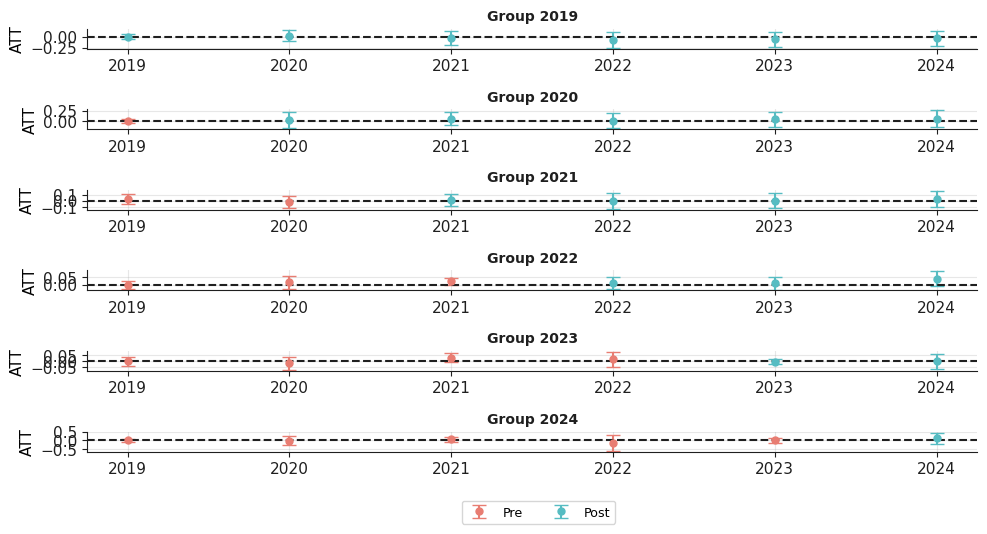

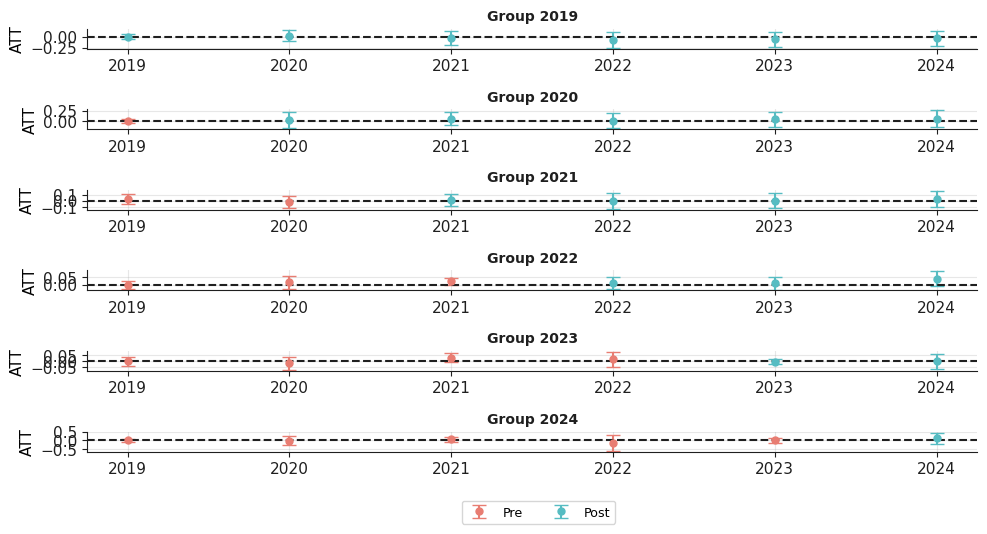

In [36]:
agg.plot_attgt()

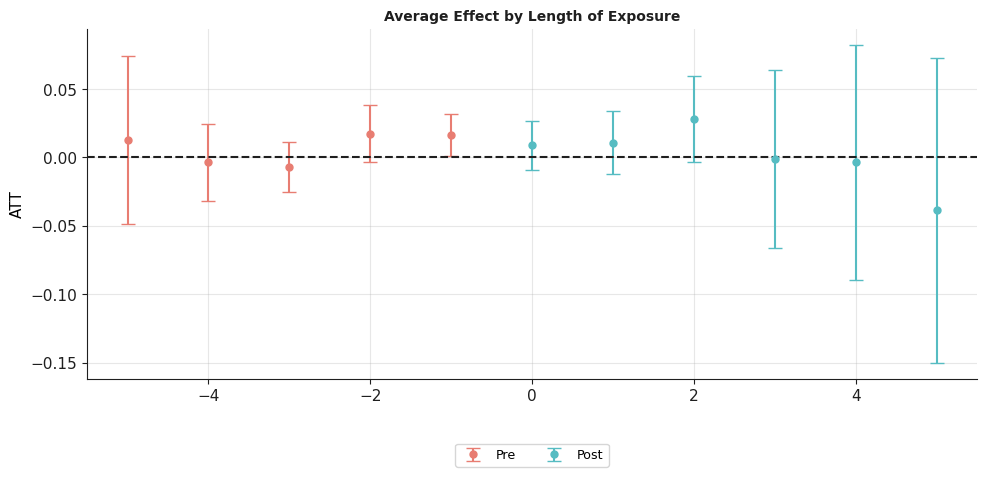

<Axes: title={'center': 'Average Effect by Length of Exposure'}, ylabel='ATT'>

In [37]:
dyn.plot_aggte()

### 5.4 Hétérogénéité - luminosité comme modérateur

Hétérogénéité par luminosité CEREMA

TWFE (Faible) : résultat
  β = 0.0590  SE = 0.0290  p = 0.042
  IC95% : [0.0022, 0.1158]
  Effet estimé : 6.08% de variation de la conso NAF84
  N = 6,266 obs, 893 communes
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
post_int       0.0590     0.0290     2.0361     0.0418      0.0022      0.1158

TWFE (Moyen) : résultat
  β = 0.0237  SE = 0.0242  p = 0.328
  IC95% : [-0.0238, 0.0712]
  Effet estimé : 2.40% de variation de la conso NAF84
  N = 6,244 obs, 892 communes
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
post_int       0.0237     0.0242     0.9781     0.3281     -0.0

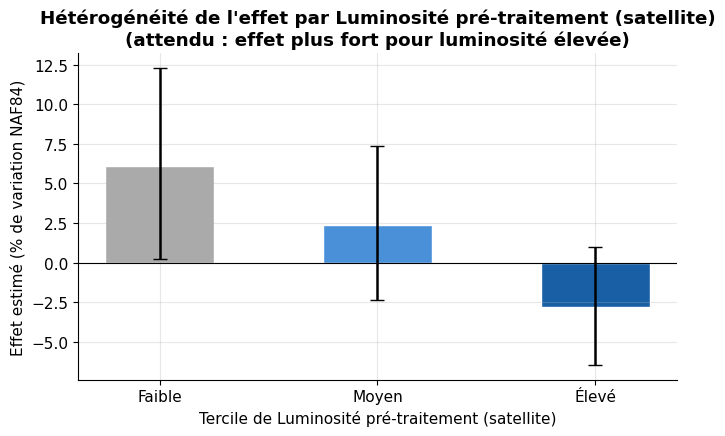

In [ ]:
#  Hétérogénéité par luminosité CEREMA 
#  On s'attend à un effet plus fort pour les communes très lumineuses.

df_het = panel_sel.copy()
df_het["post_int"] = df_het["post"].astype(int)

het_results = {}
print("Hétérogénéité par luminosité CEREMA")

# Années pré-traitement uniquement (pour éviter contamination)

pre_treatment_data = df_het[df_het["event_time"] < 0]

mean_pre_lum = pre_treatment_data.groupby("code_commune")["luminosite_annuelle"].mean()

if mean_pre_lum.notna().sum() > 50:
    commune_terciles = pd.qcut(mean_pre_lum, q=3, labels=["Faible", "Moyen", "Élevé"])
    
    df_het["lum_tercile"] = df_het["code_commune"].map(commune_terciles)
    
    group_col, label_str = "lum_tercile", "Luminosité pré-traitement (satellite)"
else:
    # Optionnel alternatif (si pas assez de données de luminosité) : même logique pour la part NAF84
    # Note : Ajustez si mean_naf84_share doit aussi être calculée sur le pré-traitement uniquement
    df_het["share_tercile"] = pd.qcut(df_het["mean_naf84_share"], q=3,
                                      labels=["Faible","Moyen","Élevé"])
    group_col, label_str = "share_tercile", "Part NAF84"


for t in ["Faible", "Moyen", "Élevé"]:
    sub = df_het[df_het[group_col] == t]
    
    # Appel de votre fonction personnalisée
    res_sub = run_twfe(sub, outcome="ln_naf84", id_col="code_commune", label=f"({t})")
    
    # Si l'estimation a réussi, on stocke le dictionnaire de résultats
    if res_sub is not None:
        het_results[t] = res_sub

#  Figure 7 : hétérogénéité 
if het_results:
    fig, ax = plt.subplots(figsize=(7, 4.5))
    terciles = list(het_results.keys())
    
    pcts = [het_results[t]["pct_effect"] for t in terciles]
    
    yerr_lo = [pcts[i] - 100 * (np.exp(het_results[t]["ci_lo"]) - 1) for i, t in enumerate(terciles)]
    yerr_hi = [100 * (np.exp(het_results[t]["ci_hi"]) - 1) - pcts[i] for i, t in enumerate(terciles)]
    
    ax.bar(terciles, pcts, color=[GRAY, "#4A90D9", BLUE], edgecolor="white", width=0.5)
    ax.errorbar(terciles, pcts,
                yerr=[yerr_lo, yerr_hi],
                fmt="none", color="black", capsize=5, lw=1.8)
    
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylabel("Effet estimé (% de variation NAF84)")
    ax.set_xlabel(f"Tercile de {label_str}")
    ax.set_title(f"Hétérogénéité de l'effet par {label_str}\n"
                 f"(attendu : effet plus fort pour luminosité élevée)", fontweight="bold")
    fig.tight_layout()
    fig.savefig("figures/fig7_heterogeneity.pdf", bbox_inches="tight")
    plt.show()


## 6. Économies monétaires

In [40]:
#  Prix TRV professionnel (source CRE) 
TRV = {2011:105, 2012:112, 2013:118, 2014:123, 2015:128, 2016:130,
       2017:132, 2018:135, 2019:142, 2020:145, 2021:148, 2022:230, 2023:210, 2024:200}

# β retenu (Callaway-Sant'Anna si disponible, sinon TWFE principal)
if not np.isnan(theta_cs) and theta_cs < 0:
    beta_used, source_beta = theta_cs, "Callaway-Sant'Anna"
elif res_main:
    beta_used, source_beta = res_main["beta"], "TWFE principal"
else:
    beta_used, source_beta = -0.12, "Hypothèse (-12%)"
    print(" Aucune estimation disponible, utilisation de -12% par défaut")

pct_reduction = 1 - np.exp(beta_used)
print(f"β utilisé = {beta_used:.4f} (source : {source_beta})")
print(f"Réduction estimée : {pct_reduction:.2%} de la conso NAF84")

# Baseline pré-extinction par commune
baseline = (
    panel_sel[~panel_sel["post"]]
    .groupby("code_commune")["conso_naf84_mwh"].mean()
    .reset_index().rename(columns={"conso_naf84_mwh":"baseline_mwh"})
)

# Observations post-traitement
savings = panel_sel[panel_sel["treated"] & panel_sel["post"]].copy()
savings = savings.merge(baseline, on="code_commune", how="left")
savings["prix_eur_mwh"]   = savings["annee"].map(TRV)
savings["mwh_economises"] = savings["baseline_mwh"] * pct_reduction
savings["eur_economises"] = savings["mwh_economises"] * savings["prix_eur_mwh"]

print(f"\n=== Économies estimées ===")
print(f"  Communes traitées (post) : {savings['code_commune'].nunique():,}")
print(f"  Total MWh économisés     : {savings['mwh_economises'].sum():,.0f} MWh")
print(f"  Total € économisés       : {savings['eur_economises'].sum()/1e6:.2f} M€")
print(f"  Moy. annuelle/commune    : {savings.groupby('code_commune')['mwh_economises'].mean().mean():,.0f} MWh")
print(f"  Moy. annuelle/commune    : {savings.groupby('code_commune')['eur_economises'].mean().mean():,.0f} €")

β utilisé = 0.0433 (source : TWFE principal)
Réduction estimée : -4.42% de la conso NAF84

=== Économies estimées ===
  Communes traitées (post) : 3,226
  Total MWh économisés     : -390,426 MWh
  Total € économisés       : -80.44 M€
  Moy. annuelle/commune    : -47 MWh
  Moy. annuelle/commune    : -9,787 €


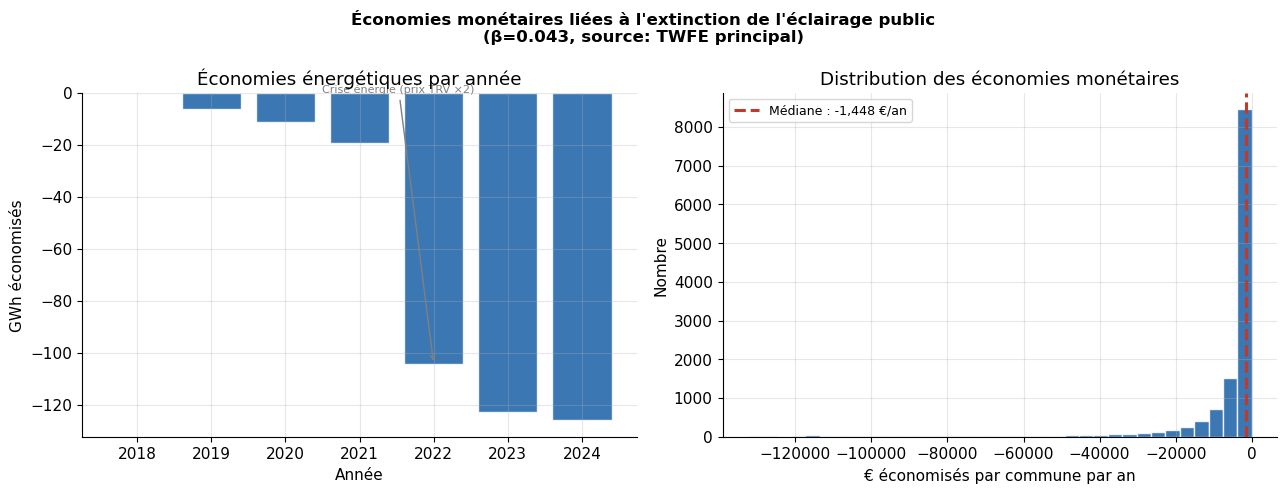

In [41]:
#  Prix implicite réel (question bonus) 
# On peut calculer le prix réel payé par les communes depuis la colonne 'Electricité'
# (= conso totale toutes filières) et les données budgétaires si disponibles.
# Sans budget : on utilise le TRV comme approximation.

#  Figure 8 : profil temporel des économies 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
by_year = savings.groupby("annee")[["mwh_economises","eur_economises"]].sum()
ax.bar(by_year.index, by_year["mwh_economises"]/1e3, color=BLUE, alpha=0.85, edgecolor="white")
ax.set_xlabel("Année"); ax.set_ylabel("GWh économisés")
ax.set_title("Économies énergétiques par année")
# Annoter le pic 2022 (crise énergétique)
if 2022 in by_year.index:
    ax.annotate("Crise énergie (prix TRV ×2)", xy=(2022, by_year.loc[2022,"mwh_economises"]/1e3),
                xytext=(2020.5, by_year["mwh_economises"].max()/1e3*0.85),
                arrowprops=dict(arrowstyle="->", color="gray"), fontsize=8, color="gray")

ax = axes[1]
per_unit = savings.groupby(["code_commune","annee"])["eur_economises"].sum()
per_unit.hist(bins=35, ax=ax, color=BLUE, alpha=0.85, edgecolor="white")
med = per_unit.median()
ax.axvline(med, color=RED, lw=2.2, linestyle="--", label=f"Médiane : {med:,.0f} €/an")
ax.set_xlabel("€ économisés par commune par an")
ax.set_ylabel("Nombre")
ax.set_title("Distribution des économies monétaires")
ax.legend(fontsize=9)

fig.suptitle("Économies monétaires liées à l'extinction de l'éclairage public\n"
             f"(β={beta_used:.3f}, source: {source_beta})", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig("figures/fig8_savings.pdf", bbox_inches="tight")
plt.show()

In [42]:
#  Analyse coût-bénéfice 
CAPEX  = 30_000   # € par commune (retrofit LED, source ADEME/CEREMA)
RATE   = 0.04     # taux d'actualisation municipal
YEARS_NPV = 20    # durée de vie LED

annual_savings = (
    savings.groupby(["code_commune","annee"])["eur_economises"].sum()
    .groupby("code_commune").mean().mean()
) if len(savings) > 0 else 0

if annual_savings > 0:
    npv = annual_savings * sum(1/(1+RATE)**t for t in range(1, YEARS_NPV+1))
    npv_net  = npv - CAPEX
    payback  = CAPEX / annual_savings
    bcr      = npv / CAPEX
    print(" Analyse Coût-Bénéfice")
    print(f"  Hypothèses : CAPEX={CAPEX:,}€ | r={RATE:.0%} | durée={YEARS_NPV} ans")
    print(f"  Économies annuelles moyennes : {annual_savings:,.0f} €/commune")
    print(f"  VAN des économies (20 ans)   : {npv:,.0f} €")
    print(f"  VAN nette                    : {npv_net:,.0f} €")
    print(f"  Ratio B/C                    : {bcr:.2f}")
    print(f"  Temps de retour              : {payback:.1f} ans")